# Mosna Analysis

## preprocessing without normalization

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning
warnings.simplefilter('ignore', FitFailedWarning)
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', DeprecationWarning)
warnings.simplefilter('ignore', UserWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from time import time
import warnings
import joblib
from pathlib import Path
from time import time
from tqdm import tqdm
import copy
import matplotlib as mpl
import napari
import colorcet as cc
import composition_stats as cs
from sklearn.impute import KNNImputer
from lifelines import KaplanMeierFitter, CoxPHFitter

from tysserand import tysserand as ty
from mosna.mosna import mosna

import matplotlib as mpl
mpl.rcParams["figure.facecolor"] = 'white'
mpl.rcParams["axes.facecolor"] = 'white'
mpl.rcParams["savefig.facecolor"] = 'white'

2025-04-09 14:05:43.560207: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-09 14:05:43.564069: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-09 14:05:43.602194: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-09 14:05:43.631765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744200343.662807    6143 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744200343.67

In [2]:
import glob
import re

objects_path = glob.glob("data/processed/Bram_IMC/acquired_csv_files/*.csv")
files=dict()



sample_number=1
for file in objects_path:
    name_file = str(Path(file).name)
    name_file = re.split(r'[_.-]', name_file)
    name_file = name_file = [str(x) for x in name_file[1:3]]
    if Path(file).with_suffix('.parquet').exists():
        obj = pd.read_parquet(Path(file).with_suffix('.parquet'))
        obj.drop(columns='Unnamed: 0', inplace=True)
        obj['patient'] = name_file[0]
        obj['sample'] = name_file[1]
        files.setdefault(f'sample {sample_number}', obj)
    else:
        obj = pd.read_csv(Path(file))
        obj.to_parquet(Path(file).with_suffix('.parquet'))
        obj.drop(columns='Unnamed: 0', inplace=True)
        obj['patient'] = name_file[0]
        obj['sample'] = name_file[1]
        files.setdefault(f'sample {sample_number}', obj)
    
    sample_number+=1
        
    

In [3]:
verif = files["sample 1"].columns
concatanable = True

for file in files.values():
    
    if file.columns.all() != verif.all():
        print("not concatanable files")
        concatanable = False

nb_row=0
nb_row_concat=0
if concatanable:
    concat_obj=pd.DataFrame()
    for file in files.values():
        nb_row+=file.shape[0]
        concat_obj = pd.concat([concat_obj, file], ignore_index=True)
    nb_row_concat=concat_obj.shape[0]

if nb_row == nb_row_concat:
    print(f"Concaténation réussite, nombre de row : {nb_row_concat}")



Concaténation réussite, nombre de row : 401568


In [4]:
### sample n° --> cell-ID 
cell_ID = pd.Series([i for i in range(len(concat_obj))], name='cell_ID')
sample_cell = pd.concat([cell_ID,concat_obj[['patient','sample']]],axis=1)
sample_cell

,cell_ID,patient,sample
0,0,16,01
1,1,16,01
2,2,16,01
3,3,16,01
4,4,16,01
...,...,...,...
401563,401563,09,03
401564,401564,09,03
401565,401565,09,03
401566,401566,09,03


In [5]:
cell_pos=pd.concat([sample_cell['cell_ID'],concat_obj[['X_position','Y_position']]],axis=1)
concat_obj.drop(columns=['X_position','Y_position','patient','sample'], inplace=True)
cell_pos

,cell_ID,X_position,Y_position
0,0,18.241379,4.396552
1,1,26.440000,2.880000
2,2,34.518520,2.962963
3,3,76.842100,1.789474
4,4,93.074070,3.203704
...,...,...,...
401563,401563,2419.544000,1459.491200
401564,401564,2503.869600,1460.275400
401565,401565,2567.476000,1460.809600
401566,401566,2583.015400,1459.384600


In [6]:
concat_obj

,aSMA_Cd110,CD3_Sm152,CD4_Gd156,CD8_Dy162,CD11b_Sm149,CD11c_Sm154,CD14_Nd144,CD15_Y89,CD16_Nd146,CD20_Nd142,...,FoxP3_Gd155,GrB_Er167,HLA-DR_Yb174,Ki67_Er168,Lag3_Eu153,PanCK_Nd148,PD1_Ho165,PDL1_Lu175,Tim3_Yb171,Vim_Nd143
0,0.670535,0.773695,0.412637,1.925640,3.060393,0.670535,0.395444,5.759728,0.103159,0.567376,...,0.085966,3.576189,4.573396,0.120353,0.034386,0.051580,0.395444,0.017193,1.822481,0.429830
1,0.478659,2.313519,0.239330,1.435978,0.159553,0.079777,0.797765,3.988827,0.159553,0.119665,...,0.039888,0.319106,2.153966,0.000000,0.199441,0.358994,0.239330,0.000000,4.866368,1.356201
2,0.295469,0.184668,0.627871,0.295469,0.295469,0.775605,1.809745,9.122594,0.664804,0.517070,...,0.000000,0.110801,28.254187,0.000000,0.110801,0.258535,0.036934,0.258535,1.957480,0.738672
3,2.466774,0.104969,0.104969,0.104969,0.209938,0.262423,0.629815,3.516465,0.209938,0.104969,...,0.000000,0.367392,1.889444,0.000000,0.000000,0.052485,0.000000,0.052485,1.994413,1.102176
4,0.073867,0.313935,0.313935,0.258535,0.960273,0.295469,3.508690,6.740378,0.110801,0.166201,...,0.073867,0.055400,3.970360,0.203135,0.092334,2.825419,0.110801,0.018467,6.740378,0.554004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401563,0.034921,0.680967,1.327012,0.279371,0.296832,0.034921,1.012720,0.069843,0.104764,0.192068,...,0.331753,0.017461,7.490634,0.000000,0.034921,0.087303,0.174607,0.034921,4.836610,0.803191
401564,0.100968,0.158664,0.317329,0.158664,0.187513,0.072120,0.865443,0.230785,0.375025,0.230785,...,0.028848,0.288481,6.231187,0.000000,0.014424,0.144240,0.072120,0.043272,2.120334,1.052955
401565,0.142180,0.236966,0.236966,0.379146,1.563978,0.000000,2.796204,0.189573,0.616113,0.142180,...,0.000000,0.000000,6.492880,0.047393,0.000000,0.094787,0.142180,0.094787,1.753552,1.753552
401566,0.122493,0.428727,0.214363,0.244987,1.255558,0.336857,5.450957,0.137805,0.704337,0.244987,...,0.030623,0.091870,4.072906,0.061247,0.045935,0.122493,0.061247,0.030623,4.011660,0.842142


In [7]:
del files, verif, nb_row, nb_row_concat, sample_number, concatanable, cell_ID, file, name_file, obj, objects_path

## Tysserand Networks 

### Select Patient and sample

In [8]:
print(sample_cell[['patient','sample']].drop_duplicates().sort_values(by='patient', ascending=True))

       patient sample
301697      04     02
60290       04     03
258601      04     01
379771      09     03
74751       09     01
117984      09     02
322206      11     01
133038      11     03
173205      11     02
189624      11     04
269467      16     02
0           16     01
225815      16     03
297495       3     02
43807        3     01
205507       3  02bis
362157      33     03
33617       33     01
343597      33     02


In [19]:
patient = '04'  # @param {type:"string"}
sample = '01'    # @param {type:"string"}
threshold = 20000 # nombre de cells a ne pas depasser pour certain graph a plot

filtre = (sample_cell['patient'] == patient) & (sample_cell['sample'] == sample)
nb_cells = filtre.sum()
print(f"Nombre de cells présente dans le sample {sample} : {nb_cells}")
cells = sample_cell.loc[filtre, 'cell_ID']

Nombre de cells présente dans le sample 01 : 10866


### Normalize markers data

In [10]:
markers_by_patient_sample = concat_obj.loc[filtre]
markers_by_patient_sample

,aSMA_Cd110,CD3_Sm152,CD4_Gd156,CD8_Dy162,CD11b_Sm149,CD11c_Sm154,CD14_Nd144,CD15_Y89,CD16_Nd146,CD20_Nd142,...,FoxP3_Gd155,GrB_Er167,HLA-DR_Yb174,Ki67_Er168,Lag3_Eu153,PanCK_Nd148,PD1_Ho165,PDL1_Lu175,Tim3_Yb171,Vim_Nd143
258601,0.183776,0.761357,0.131268,0.000000,0.262537,0.131268,0.708850,0.105015,0.183776,0.105015,...,0.000000,0.052507,0.498820,0.000000,0.000000,0.000000,0.105015,0.000000,2.415339,0.498820
258602,0.076742,0.422079,0.230225,0.000000,0.306966,0.076742,0.383708,0.268595,0.076742,0.000000,...,0.038371,0.115112,5.448650,0.038371,0.038371,0.000000,0.115112,0.038371,1.189494,0.767416
258603,0.345337,0.767416,0.000000,0.153483,0.115112,0.230225,0.383708,0.115112,0.000000,0.000000,...,0.115112,0.000000,0.345337,0.000000,0.000000,0.115112,0.115112,0.000000,5.678875,2.033651
258604,0.234739,0.586847,0.058685,0.000000,0.117369,0.117369,0.469478,0.234739,0.058685,0.000000,...,0.000000,0.058685,0.058685,0.000000,0.058685,0.058685,0.000000,0.000000,4.342669,1.349749
258605,0.000000,1.479260,0.240810,0.240810,0.206408,0.206408,0.447218,1.032042,0.068803,0.034401,...,0.068803,0.034401,3.818554,0.000000,0.137606,0.103204,0.172007,0.068803,3.199329,1.513661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269462,1.205482,0.831367,0.249410,0.062353,0.228626,0.103921,1.350971,0.207842,0.290978,0.124705,...,0.020784,0.041568,2.577237,0.415683,0.041568,0.083137,0.124705,0.000000,4.489381,0.187058
269463,3.957306,0.266037,0.133019,0.099764,0.166273,0.199528,1.030895,0.099764,0.631839,0.033255,...,0.000000,0.033255,0.798112,0.000000,0.000000,0.033255,0.066509,0.066509,4.023816,0.066509
269464,0.213780,1.496460,0.000000,0.071260,0.570080,0.498820,0.570080,0.712600,0.142520,0.213780,...,0.000000,0.071260,0.285040,0.071260,0.071260,3.776781,0.213780,0.071260,1.638980,0.071260
269465,1.587155,0.158715,0.068021,0.045347,0.045347,0.136042,0.158715,0.068021,0.022674,0.045347,...,0.000000,0.068021,0.113368,0.022674,0.045347,0.022674,0.045347,0.090695,4.444034,0.090695


In [11]:
for markers in markers_by_patient_sample:
    # Calculate 99.9th percentile value for column
    p99_9 = markers_by_patient_sample[markers].quantile(0.999)
        
    # Ensure values above the 99.9th percentile are not more than this value
    markers_by_patient_sample[markers] = markers_by_patient_sample[markers].clip(upper=p99_9)
        
    # Normalize based on 99.9th percentile value
    markers_by_patient_sample[markers] = (markers_by_patient_sample[markers] - markers_by_patient_sample[markers].min()) / (p99_9 - markers_by_patient_sample[markers].min())

/tmp/ipykernel_6143/3634486520.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  markers_by_patient_sample[markers] = markers_by_patient_sample[markers].clip(upper=p99_9)
/tmp/ipykernel_6143/3634486520.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  markers_by_patient_sample[markers] = (markers_by_patient_sample[markers] - markers_by_patient_sample[markers].min()) / (p99_9 - markers_by_patient_sample[markers].min())
/tmp/ipykernel_6143/3634486520.py:6: SettingWithCopyWarning: 
A value is trying to be 

In [ ]:
from phenograph.cluster import cluster

k_neighbors = 30
# Use clustering method from phenograph package to construct phenograph
clustering, graph, Q = cluster(markers_by_patient_sample, 
                                    k = k_neighbors,                      # k=30 is default
                                    primary_metric = 'minkowski',         # minkowski is default
                                    seed = 10,                            # To ensure reproducibility: we pick seed=10 from start
                                    n_jobs = 1)

# Add the cluster assignments back to the original DataFrame
# graph is a sparse matrix so we need some other steps to plot it

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.2623260021209717 seconds
Jaccard graph constructed in 1.45912766456604 seconds
Wrote graph to binary file in 0.07634568214416504 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.771699
After 3 runs, maximum modularity is Q = 0.773114
Louvain completed 23 runs in 2.6099681854248047 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 4.627910614013672 seconds


In [ ]:
if nb_cells < threshold:
    import networkx as nx
    from matplotlib.patches import Patch

    G = nx.from_scipy_sparse_array(graph, edge_attribute='weight')

    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, seed=42)  # Layout force-directed

    # Create color for each cluster
    colors = [clustering[i] for i in range(len(clustering))]
    unique_clusters = sorted(set(clustering))
    cmap = plt.cm.tab20
    legend_elements = [Patch(facecolor=cmap(i % cmap.N), label=f"Cluster {i}") for i in unique_clusters]

    nx.draw(G, pos, node_size=10, edge_color='gray', node_color=colors, cmap=cmap, alpha=0.5, width=0.01, with_labels=False)
    plt.legend(handles=legend_elements, title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f"Similarity graph (PhenoGraph) for a clustering quality of = {Q}")
    plt.tight_layout()
    plt.show()

### Tysserand network

In [21]:
if clustering is not None:
    nb_clust = clustering.max()
    uniq = pd.Series(clustering).value_counts().index

    # choose colormap
    clusters_cmap = mosna.make_cluster_cmap(uniq)
    # make color mapper
    # series to sort by decreasing order
    n_colors = len(clusters_cmap)
    celltypes_color_mapper = {x: clusters_cmap[i % n_colors] for i, x in enumerate(uniq)}

processing patient n°04 for sample n°01
there are 18/10866 nodes with < 3 edges


Text(0.5, 1.0, 'Draw a Tysserand network for patient 04 and sample 01')

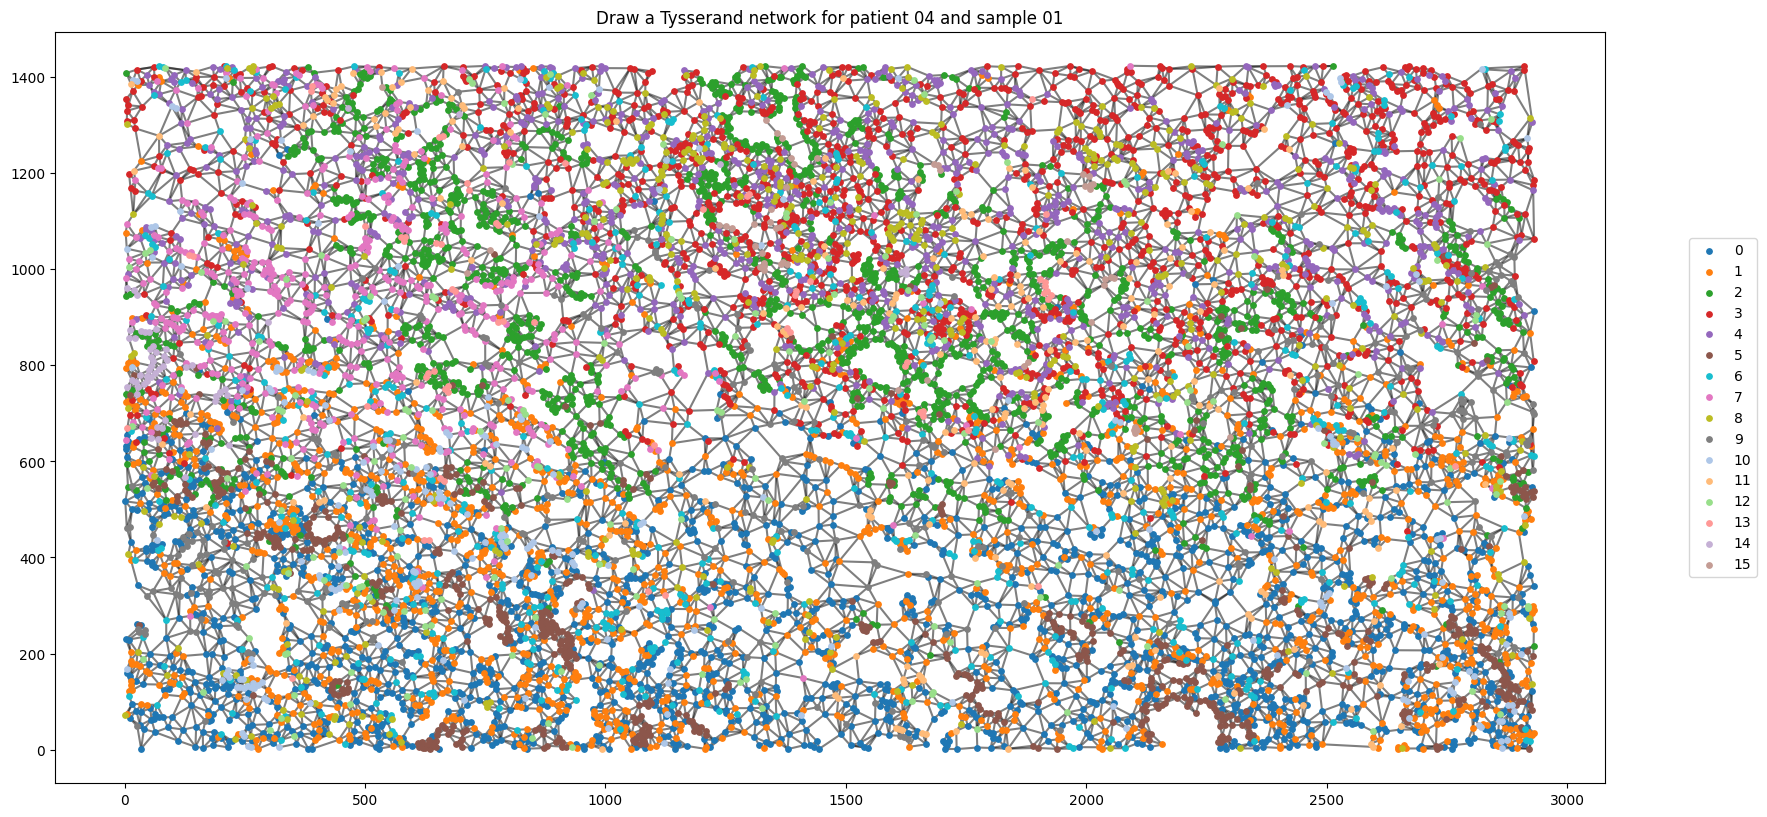

In [24]:
filtre = cell_pos['cell_ID'].isin(cells)
coords = cell_pos.loc[filtre, ['X_position','Y_position']]

print(f"processing patient n°{patient} for sample n°{sample}")
coords = np.array(coords.values.tolist())
pairs = ty.build_delaunay(coords)
    # we want to avoid isolated cells, so we link them to their 3 closest neighbors
pairs = ty.link_solitaries(coords, pairs, method='delaunay', min_neighbors=3)

fig, ax = ty.plot_network(
    coords, pairs,labels=clustering,
    color_mapper=celltypes_color_mapper,
    legend_opt={'loc': 'center left', 'bbox_to_anchor': (1.05, 0.5)},
    size_nodes=15,
    figsize=(20,20)
    )
plt.title(f"Draw a Tysserand network for patient {patient} and sample {sample}")